In [25]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)


In [3]:
type(train_set), train_set.data.shape, train_set.targets.shape

(torchvision.datasets.mnist.MNIST,
 torch.Size([60000, 28, 28]),
 torch.Size([60000]))

In [ ]:
train_set.targets[:10], 

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

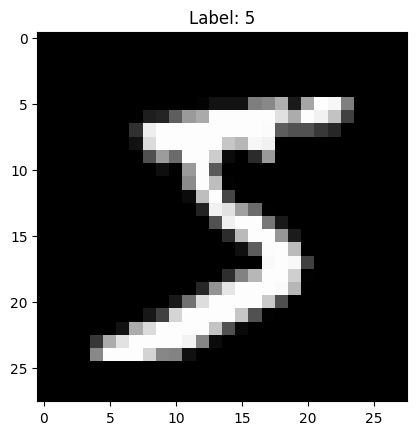

In [6]:
# show the first image 
plt.imshow(train_set.data[0], cmap='gray')
plt.title(f'Label: {train_set.targets[0]}') 
plt.show()

In [5]:
train_set.data[0], train_set.targets[0]

(tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
           18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,

In [7]:
from torch.utils.data import DataLoader, random_split

In [ ]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [10]:
train_set.targets.shape, train_set.targets[:20]

(torch.Size([60000]),
 tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9]))

In [12]:
train_set.targets.unique(), train_set.targets.bincount() 

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
count = train_set.targets.bincount() 

In [21]:
len(dir(train_set.data)) 

756

In [22]:
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [23]:
test_set.data.shape, test_set.targets.shape

(torch.Size([10000, 28, 28]), torch.Size([10000]))

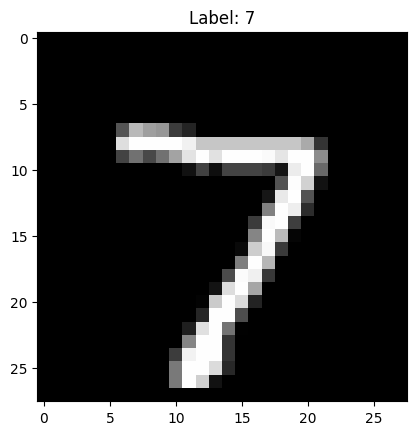

In [24]:
# show me the first image of the test set
plt.imshow(test_set.data[0], cmap='gray')   
plt.title(f'Label: {test_set.targets[0]}')
plt.show()

In [26]:
# MINST Model
class MNISTModel(torch.nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(28*28, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [27]:
model = MNISTModel()


In [32]:
train_set.data[0].shape, train_set.data[0].unsqueeze(0).shape

(torch.Size([28, 28]), torch.Size([1, 28, 28]))

In [35]:
para = model.linear_relu_stack.parameters()
next(para).shape

torch.Size([512, 784])

In [31]:
res = model.flatten(train_set.data[0].unsqueeze(0))
res.shape

torch.Size([1, 784])

In [42]:
train_set.data[0].unsqueeze(0).shape

torch.Size([1, 28, 28])

In [45]:
model.forward(train_set.data[0].unsqueeze(0).to(torch.float32)).argmax(dim=1), train_set.targets[0]

(tensor([9]), tensor(5))

In [38]:
train_set.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   